## 02611 Optimization for Data Science
### Assignment: Logistic Regression


In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.preprocessing import StandardScaler

X, y = sklearn.datasets.load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
y = 2 * y - 1

N, n = X.shape
X_tilde = np.hstack([X, np.ones((N, 1))])

D = np.eye(n + 1)
D[-1, -1] = 0.0

def sigmoid(z):
    return np.where(
        z >= 0,
        1.0 / (1.0 + np.exp(-z)),
        np.exp(z) / (1.0 + np.exp(z))
    )

def phi(s):
    return np.logaddexp(0.0, s)

def neg_log_likelihood(theta):
    z = -y * (X_tilde @ theta)
    return np.sum(phi(z))

def objective(theta, gamma):
    return neg_log_likelihood(theta) + 0.5 * gamma * np.linalg.norm(D @ theta)**2

def gradient(theta, gamma):
    z = -y * (X_tilde @ theta)
    q = sigmoid(z)
    return -X_tilde.T @ (y * q) + gamma * (D @ theta)

def lipschitz_constant(gamma):
    return gamma + 0.25 * np.linalg.norm(X_tilde, 2)**2

### Q5: GD vs accelerated GD

L = 1892.308693
Step size alpha = 5.284550e-04
Final objective (GD):  48.219119
Final objective (AGD): 48.077793


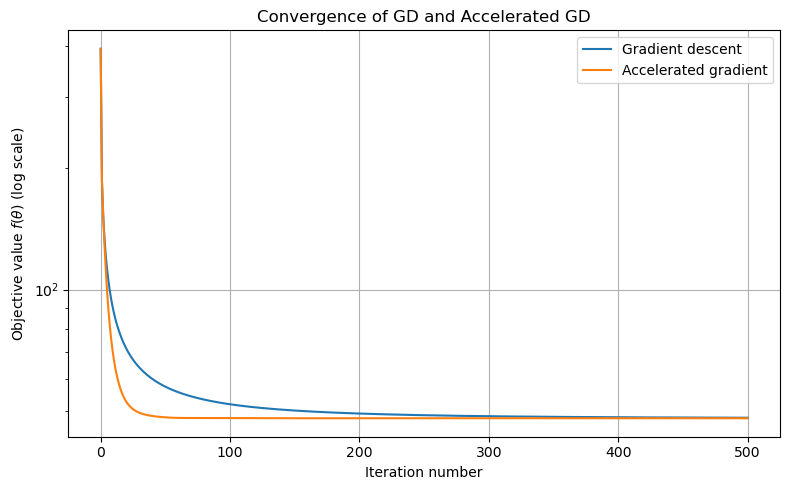

In [3]:
gamma = 3.0
L = lipschitz_constant(gamma)
alpha = 1.0 / L

def gradient_descent(theta0, gamma, max_iter=500):
    theta = theta0.copy()
    values = [objective(theta, gamma)]
    alpha = 1.0 / lipschitz_constant(gamma)

    for _ in range(max_iter):
        theta = theta - alpha * gradient(theta, gamma)
        values.append(objective(theta, gamma))

    return theta, np.array(values)

def accelerated_gradient(theta0, gamma, max_iter=500, tol=None):
    theta = theta0.copy()
    v = theta0.copy()
    t = 1.0
    alpha = 1.0 / lipschitz_constant(gamma)

    values = [objective(theta, gamma)]

    for _ in range(max_iter):
        theta_new = v - alpha * gradient(v, gamma)
        values.append(objective(theta_new, gamma))

        if tol is not None:
            if np.linalg.norm(theta_new - theta) < tol * max(1.0, np.linalg.norm(theta)):
                theta = theta_new
                break

        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t**2))
        v = theta_new + ((t - 1.0) / t_new) * (theta_new - theta)

        theta = theta_new
        t = t_new

    return theta, np.array(values)

theta0 = np.zeros(n + 1)

theta_gd, vals_gd = gradient_descent(theta0, gamma, max_iter=500)
theta_agd, vals_agd = accelerated_gradient(theta0, gamma, max_iter=500)

print(f"L = {L:.6f}")
print(f"Step size alpha = {alpha:.6e}")
print(f"Final objective (GD):  {vals_gd[-1]:.6f}")
print(f"Final objective (AGD): {vals_agd[-1]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(vals_gd, label="Gradient descent")
plt.plot(vals_agd, label="Accelerated gradient")
plt.yscale("log")
plt.xlabel("Iteration number")
plt.ylabel(r"Objective value $f(\theta)$ (log scale)")
plt.title("Convergence of GD and Accelerated GD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Q5.png", dpi=300, bbox_inches="tight")
plt.show()

### Q6: Trade-off curve

gamma        0.5||Dtheta||^2        -logL(theta)
1.000e-03     846.789174          14.815973
3.793e-02     81.193993          19.860737
1.438e+00     5.980521          32.055066
5.456e+01     0.626336          76.332260
1.000e+03     0.055789          194.576955


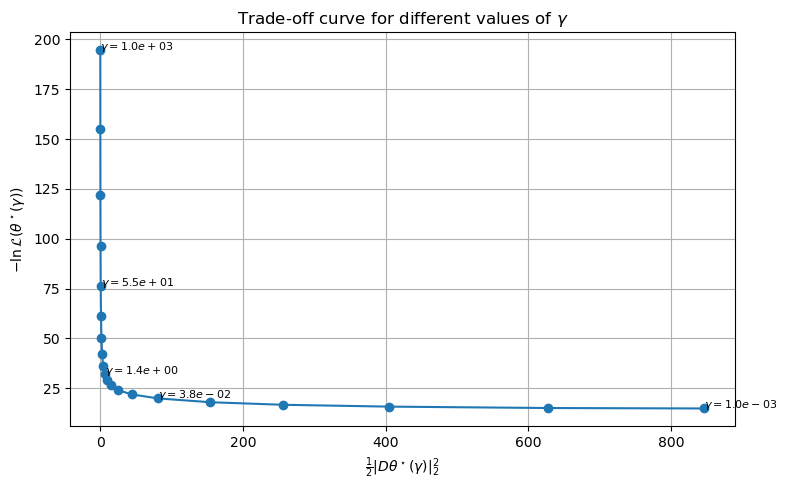

In [4]:
gammas = np.logspace(-3, 3, 20)

reg_values = []
nll_values = []

theta = np.zeros(n + 1)

for gamma in gammas:
    theta, _ = accelerated_gradient(theta, gamma, max_iter=2000, tol=1e-10)

    reg_values.append(0.5 * np.linalg.norm(D @ theta)**2)
    nll_values.append(neg_log_likelihood(theta))

reg_values = np.array(reg_values)
nll_values = np.array(nll_values)

plt.figure(figsize=(8, 5))
plt.plot(reg_values, nll_values, marker="o")

for i in [0, 5, 10, 15, 19]:
    plt.annotate(
        fr"$\gamma={gammas[i]:.1e}$",
        (reg_values[i], nll_values[i]),
        fontsize=8
    )

print("gamma        0.5||Dtheta||^2        -logL(theta)")
for i in [0, 5, 10, 15, 19]:
    print(f"{gammas[i]:.3e}     {reg_values[i]:.6f}          {nll_values[i]:.6f}")

plt.xlabel(r"$\frac{1}{2}\|D\theta^\star(\gamma)\|_2^2$")
plt.ylabel(r"$-\ln \mathcal{L}(\theta^\star(\gamma))$")
plt.title(r"Trade-off curve for different values of $\gamma$")
plt.grid(True)
plt.tight_layout()
plt.savefig("Q6.png", dpi=300, bbox_inches="tight")
plt.show()